#과일 Data를 cnn으로 Image 분류


In [67]:
#넘파이 데이터:이미지=>넘파이
import warnings
warnings.filterwarnings('ignore')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.model_selection import train_test_split


In [68]:
#과일 데이터 불러오기
import numpy as np
fruits=np.load("../Data/fruits.npy")
fruits.shape#300장

(300, 100, 100)

In [69]:
fruits[:2]#1,2번째 이미지

array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]]], shape=(2, 100, 100), dtype=int32)

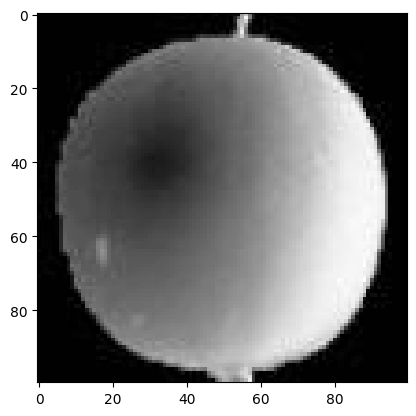

In [70]:
#Image 확인하기
import matplotlib.pyplot as plt
plt.imshow(fruits[0].reshape(100,100),cmap='gray')#3=>1차원
plt.show()

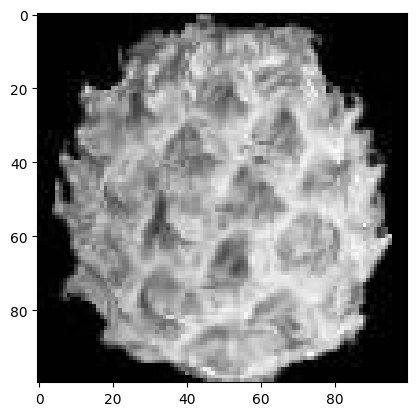

In [71]:
import matplotlib.pyplot as plt
plt.imshow(fruits[100].reshape(100,100),cmap='gray')#3=>1차원
plt.show()

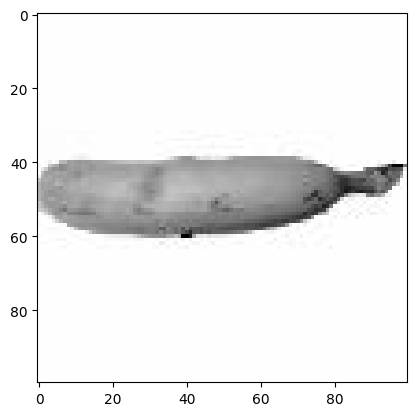

In [72]:
import matplotlib.pyplot as plt
plt.imshow(fruits[200].reshape(100,100),cmap='gray_r')#3=>1차원
plt.show()

In [73]:
#인공신경망 cnn 지도학습
#Target 만들기
target=np.concatenate(
[
    np.zeros(100),
    np.ones(100),
    np.full(100,2)
]
)#뭉치다. append
target.shape

(300,)

In [74]:
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2.

1.Train과 Target로 분류하기
2.CNN 만들기
3.시각화(손실loss/valoss)
4.평가
5.이미지로 예측하기

In [75]:
train_input, test_input, train_target, test_target = train_test_split(
    fruits, target, test_size=0.2, random_state=42, stratify=target
)

train_input.shape
train_scaled=train_input.reshape(-1,100,100,1)/255.0
train_scaled.shape

train_scaled,val_scaled,train_target,val_target=train_test_split(
    train_scaled,train_target,test_size=0.2,random_state=42
)

In [76]:
model= keras.Sequential()

In [77]:
model.add(
    keras.layers.Conv2D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(100, 100, 1)
    )
)

model.add(keras.layers.MaxPool2D(2))

In [78]:

model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same'
))
model.add(keras.layers.MaxPool2D(2))

In [79]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(3,activation='softmax'))

In [80]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 40000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │     4,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,019,219 (15.33 MB)

 Trainable params: 4,019,219 (15.33 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

checkpoint_cb= keras.callbacks.ModelCheckpoint("../Data/best_model.keras")
early_stopping_cb= keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)#early stopping=>patience
#에포크 작게 할필요없음. 보통 첫번째 에포크의 정확도는 높지않음.    
history=model.fit(train_scaled,train_target,epochs=20, validation_data=(val_scaled,val_target),callbacks=[checkpoint_cb,early_stopping_cb])

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5781 - loss: 0.8267 - val_accuracy: 1.0000 - val_loss: 0.4375
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9635 - loss: 0.2080 - val_accuracy: 1.0000 - val_loss: 0.0266
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9948 - loss: 0.0247 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - val_loss: 0.0133
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 3.7129e-04
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 1.3281e-05
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 1.0000 - loss: 1.6996e-04 - val_accuracy: 1.0000 - val_loss: 1.3030e-05
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9948 - loss: 0.0054 - val_accuracy: 1.000

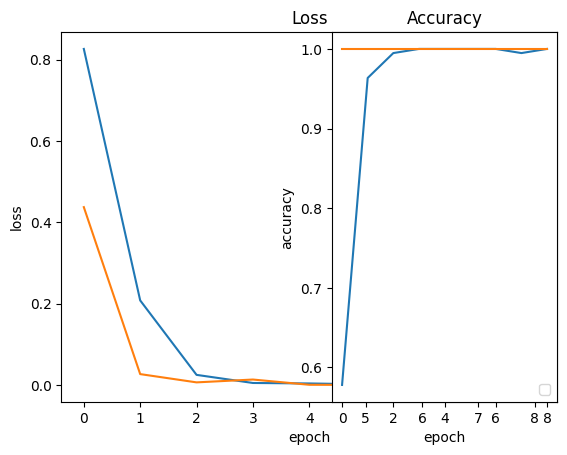

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9333 - loss: 19.4009


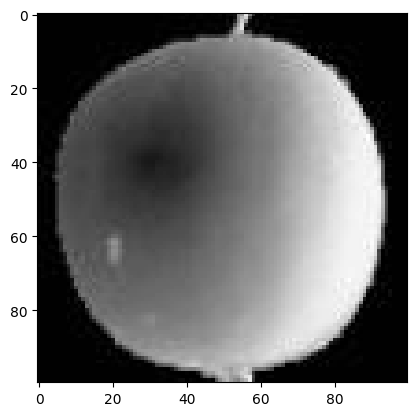

In [82]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()


model.evaluate(test_input, test_target)

plt.imshow(test_input[0].reshape(100, 100), cmap='gray')


In [83]:
pred = model.predict(test_input[:1])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[1. 0. 0.]]


In [84]:
#글자로 변경하기
import numpy as np
classes=['사과','바나나','파인애플']

print(classes[np.argmax(pred)])

사과
